In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


In [2]:
# Las hipótesis guían todo el análisis.
# Las planteamos ANTES de ver los datos para evitar sesgos.

# H6: El perfil de atributos del metal es estructuralmente opuesto
#     al perfil de las canciones más populares.
#     (baja danceability, baja valence, alta instrumentalness)

# H7: El alt-rock y alternative tienen un perfil más cercano al mainstream
#     (mayor danceability y valence) que el heavy-metal.

# H8: Dentro del metal, las canciones más populares tienen atributos
#     más cercanos al pop — más danceability, más valence, menos instrumentalness.

# H9: El hip-hop y reggaeton dominan en popularidad porque maximizan
#     exactamente los atributos que el algoritmo de Spotify premia.

print('Hipótesis definidas ✓')
print()
print('H6 — Metal vs perfil mainstream')
print('H7 — Subgéneros rock: ¿cuál está más cerca del mainstream?')
print('H8 — Dentro del metal, ¿las populares traicionan el género?')
print('H9 — ¿Hip-hop y reggaeton encajan perfecto con el algoritmo?')

Hipótesis definidas ✓

H6 — Metal vs perfil mainstream
H7 — Subgéneros rock: ¿cuál está más cerca del mainstream?
H8 — Dentro del metal, ¿las populares traicionan el género?
H9 — ¿Hip-hop y reggaeton encajan perfecto con el algoritmo?


In [3]:
# Cargamos el CSV
df = pd.read_csv('dataset.csv', index_col=0)

print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print()
df.head()

Filas:    114,000
Columnas: 20



,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# Tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

In [5]:
df.describe().round(2)

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00
mean,33.24,228029.15,0.57,0.64,5.31,-8.26,0.64,0.08,0.31,0.16,0.21,0.47,122.15,3.90
std,22.31,107297.71,0.17,0.25,3.56,5.03,0.48,0.11,0.33,0.31,0.19,0.26,29.98,0.43
min,0.00,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,17.00,174066.00,0.46,0.47,2.00,-10.01,0.00,0.04,0.02,0.00,0.10,0.26,99.22,4.00
50%,35.00,212906.00,0.58,0.68,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,50.00,261506.00,0.70,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00


In [6]:
print(f'Géneros únicos en el dataset: {df["track_genre"].nunique()}')
print()
print('Canciones por género (primeros 20):')
print(df['track_genre'].value_counts().head(20))

Géneros únicos en el dataset: 114

Canciones por género (primeros 20):
track_genre
acoustic         1000
afrobeat         1000
alt-rock         1000
alternative      1000
ambient          1000
anime            1000
black-metal      1000
bluegrass        1000
blues            1000
brazil           1000
breakbeat        1000
british          1000
cantopop         1000
chicago-house    1000
children         1000
chill            1000
classical        1000
club             1000
comedy           1000
country          1000
Name: count, dtype: int64


In [7]:
# Analizamos los nulos antes de actuar
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

reporte_nulos = pd.DataFrame({
    'Nulos': nulos, 
    'Porcentaje %': nulos_pct
})

print('Columnas con valores nulos:')
print(reporte_nulos[reporte_nulos['Nulos'] > 0])
print()

# Eliminamos filas con nulos
filas_antes = len(df)
df.dropna(inplace=True)
filas_despues = len(df)

print(f'Filas eliminadas: {filas_antes - filas_despues:,}')
print(f'Filas restantes:  {filas_despues:,}')

Columnas con valores nulos:
            Nulos  Porcentaje %
artists         1           0.0
album_name      1           0.0
track_name      1           0.0

Filas eliminadas: 1
Filas restantes:  113,999


In [8]:
# Verificamos duplicados exactos por track_id + track_genre
duplicados = df.duplicated(subset=['track_id', 'track_genre']).sum()
print(f'Duplicados exactos (mismo track + mismo género): {duplicados:,}')
print()

# Una misma canción puede aparecer en múltiples géneros — eso es intencional
# Lo que NO debería pasar es la misma canción EN el mismo género dos veces
canciones_unicas = df['track_id'].nunique()
total_filas = len(df)

print(f'Canciones únicas (track_id):  {canciones_unicas:,}')
print(f'Total filas del dataset:       {total_filas:,}')
print(f'Diferencia:                    {total_filas - canciones_unicas:,}')
print()
print('→ La diferencia es esperada: una canción puede estar en varios géneros')

# Eliminamos solo si hay duplicados reales
if duplicados > 0:
    df.drop_duplicates(subset=['track_id', 'track_genre'], inplace=True)
    print(f'Duplicados eliminados. Filas restantes: {len(df):,}')
else:
    print('Sin duplicados reales ✓')

Duplicados exactos (mismo track + mismo género): 450

Canciones únicas (track_id):  89,740
Total filas del dataset:       113,999
Diferencia:                    24,259

→ La diferencia es esperada: una canción puede estar en varios géneros
Duplicados eliminados. Filas restantes: 113,549


In [9]:
# Corregimos tipos de datos
df['explicit'] = df['explicit'].astype(bool)

# Creamos columnas derivadas útiles para el análisis
df['duration_min'] = df['duration_ms'] / 60000

print('Tipos de datos corregidos ✓')
print()
print(f'explicit dtype:     {df["explicit"].dtype}')
print(f'duration_min dtype: {df["duration_min"].dtype}')
print()
print('Muestra de duration_min:')
print(df['duration_min'].describe().round(2))

Tipos de datos corregidos ✓

explicit dtype:     bool
duration_min dtype: float64

Muestra de duration_min:
count    113549.00
mean          3.80
std           1.77
min           0.14
25%           2.90
50%           3.55
75%           4.36
max          87.29
Name: duration_min, dtype: float64


Canciones con popularidad 0: 15,843 (13.95%)



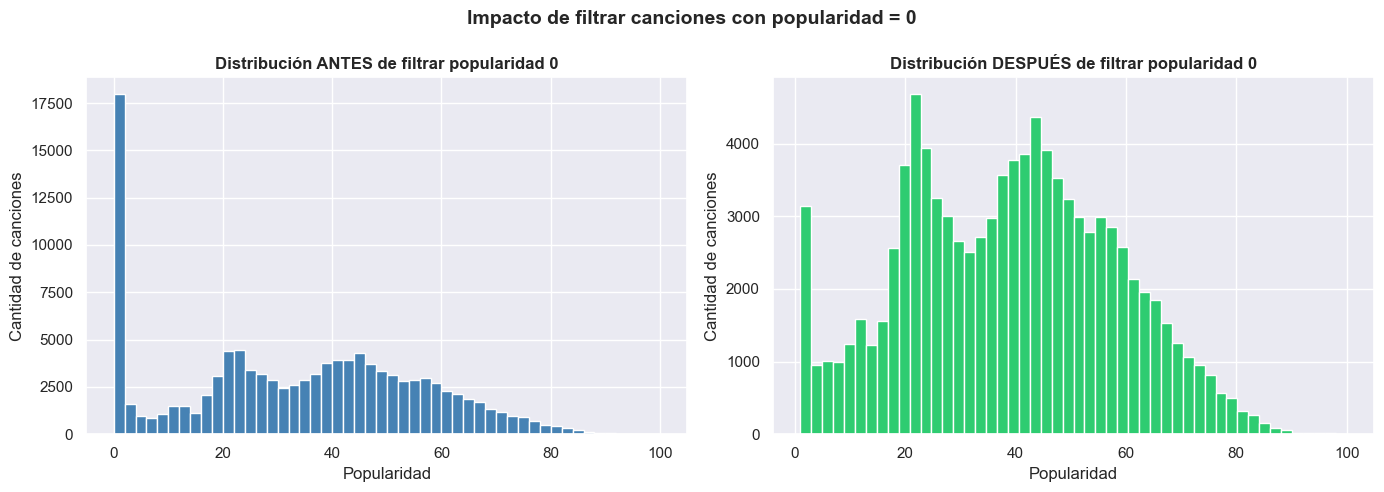

Filas después del filtro: 97,706


In [10]:
# Analizamos cuántas canciones tienen popularidad 0
pop_cero = (df['popularity'] == 0).sum()
pop_cero_pct = (pop_cero / len(df) * 100).round(2)

print(f'Canciones con popularidad 0: {pop_cero:,} ({pop_cero_pct}%)')
print()

# Visualizamos la distribución para entender el problema
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Con popularidad 0
axes[0].hist(df['popularity'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución ANTES de filtrar popularidad 0', fontweight='bold')
axes[0].set_xlabel('Popularidad')
axes[0].set_ylabel('Cantidad de canciones')

# Sin popularidad 0
df_filtrado = df[df['popularity'] > 0]
axes[1].hist(df_filtrado['popularity'], bins=50, color='#2ECC71', edgecolor='white')
axes[1].set_title('Distribución DESPUÉS de filtrar popularidad 0', fontweight='bold')
axes[1].set_xlabel('Popularidad')
axes[1].set_ylabel('Cantidad de canciones')

plt.suptitle('Impacto de filtrar canciones con popularidad = 0', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Aplicamos el filtro
df = df[df['popularity'] > 0].copy()

print(f'Filas después del filtro: {len(df):,}')

In [11]:
# Géneros seleccionados para el análisis
generos_metal_rock = ['metal', 'heavy-metal', 'alt-rock', 'alternative', 'grunge']
generos_mainstream = ['pop', 'hip-hop', 'reggaeton', 'latin', 'dance']
generos_referencia = ['jazz', 'classical']

todos_los_generos = generos_metal_rock + generos_mainstream + generos_referencia

# Atributos relevantes para nuestras hipótesis
atributos_audio = [
    'popularity', 'danceability', 'energy', 'valence',
    'instrumentalness', 'speechiness', 'tempo', 
    'loudness', 'acousticness', 'explicit'
]

# Creamos el DataFrame filtrado
df_generos = df[df['track_genre'].isin(todos_los_generos)].copy()

# Agregamos una columna de grupo para facilitar comparaciones
df_generos['grupo'] = df_generos['track_genre'].apply(
    lambda g: 'Metal/Rock' if g in generos_metal_rock 
    else ('Mainstream' if g in generos_mainstream 
    else 'Referencia')
)

print('Géneros seleccionados:')
print()
print(f'  Metal/Rock:  {generos_metal_rock}')
print(f'  Mainstream:  {generos_mainstream}')
print(f'  Referencia:  {generos_referencia}')
print()
print('Distribución de canciones por grupo:')
print(df_generos['grupo'].value_counts())
print()
print(f'Total canciones en análisis: {len(df_generos):,}')
print(f'Total dataset completo:      {len(df):,}')

Géneros seleccionados:

  Metal/Rock:  ['metal', 'heavy-metal', 'alt-rock', 'alternative', 'grunge']
  Mainstream:  ['pop', 'hip-hop', 'reggaeton', 'latin', 'dance']
  Referencia:  ['jazz', 'classical']

Distribución de canciones por grupo:
grupo
Metal/Rock    3915
Mainstream    3068
Referencia     869
Name: count, dtype: int64

Total canciones en análisis: 7,852
Total dataset completo:      97,706


In [12]:
print('═' * 45)
print('RESUMEN FINAL — DATASET LISTO PARA ANÁLISIS')
print('═' * 45)
print()
print('── Dataset completo (para perfil mainstream) ──')
print(f'  Filas:            {len(df):,}')
print(f'  Columnas:         {df.shape[1]}')
print(f'  Géneros totales:  {df["track_genre"].nunique()}')
print(f'  Artistas únicos:  {df["artists"].nunique():,}')
print(f'  Nulos:            {df.isnull().sum().sum()}')
print()
print('── Dataset filtrado (para análisis por género) ──')
print(f'  Filas:            {len(df_generos):,}')
print(f'  Géneros:          {df_generos["track_genre"].nunique()}')
print()
print('── Distribución por grupo ──')
for grupo, count in df_generos['grupo'].value_counts().items():
    pct = count / len(df_generos) * 100
    print(f'  {grupo:<12}: {count:,} canciones ({pct:.1f}%)')
print()
print('── Rango de popularidad (post-filtro) ──')
print(f'  Mínimo:   {df["popularity"].min()}')
print(f'  Máximo:   {df["popularity"].max()}')
print(f'  Media:    {df["popularity"].mean():.1f}')
print(f'  Mediana:  {df["popularity"].median():.1f}')
print()
print('Dataset listo ✓')

═════════════════════════════════════════════
RESUMEN FINAL — DATASET LISTO PARA ANÁLISIS
═════════════════════════════════════════════

── Dataset completo (para perfil mainstream) ──
  Filas:            97,706
  Columnas:         21
  Géneros totales:  114
  Artistas únicos:  29,826
  Nulos:            0

── Dataset filtrado (para análisis por género) ──
  Filas:            7,852
  Géneros:          12

── Distribución por grupo ──
  Metal/Rock  : 3,915 canciones (49.9%)
  Mainstream  : 3,068 canciones (39.1%)
  Referencia  : 869 canciones (11.1%)

── Rango de popularidad (post-filtro) ──
  Mínimo:   1
  Máximo:   100
  Media:    38.7
  Mediana:  39.0

Dataset listo ✓


In [13]:
# Dividimos el dataset completo en cuartiles de popularidad
df['pop_quartile'] = pd.qcut(
    df['popularity'], 
    q=4, 
    labels=['Q1 (baja)', 'Q2', 'Q3', 'Q4 (alta)']
)

# Calculamos el perfil promedio por cuartil
atributos_perfil = ['danceability', 'energy', 'valence', 
                    'instrumentalness', 'speechiness', 
                    'acousticness', 'tempo', 'loudness']

perfil_popularidad = df.groupby('pop_quartile')[atributos_perfil].mean().round(3)

print('Perfil de atributos por cuartil de popularidad:')
print()
print(perfil_popularidad.to_string())
print()

# Guardamos el perfil mainstream (Q4) para usarlo en H6
perfil_mainstream = perfil_popularidad.loc['Q4 (alta)']
print('── Perfil mainstream (Q4) ──')
print(perfil_mainstream)

Perfil de atributos por cuartil de popularidad:

              danceability  energy  valence  instrumentalness  speechiness  acousticness    tempo  loudness
pop_quartile                                                                                               
Q1 (baja)            0.553   0.657    0.455             0.269        0.106         0.300  123.265    -8.760
Q2                   0.552   0.664    0.505             0.139        0.090         0.315  122.896    -8.232
Q3                   0.573   0.627    0.450             0.147        0.074         0.336  123.288    -8.150
Q4 (alta)            0.587   0.636    0.466             0.099        0.076         0.287  121.266    -7.850

── Perfil mainstream (Q4) ──
danceability          0.587
energy                0.636
valence               0.466
instrumentalness      0.099
speechiness           0.076
acousticness          0.287
tempo               121.266
loudness             -7.850
Name: Q4 (alta), dtype: float64


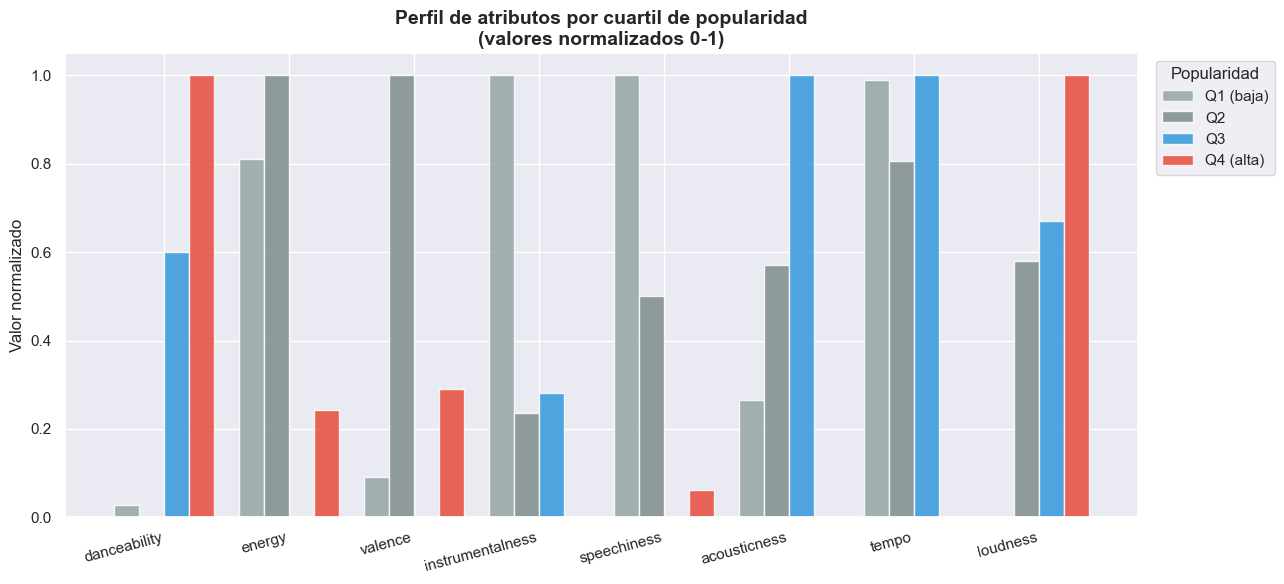

In [14]:
# Normalizamos tempo y loudness para poder graficarlos en la misma escala
# que los atributos que ya están entre 0 y 1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

perfil_para_graficar = perfil_popularidad[atributos_perfil].copy()
perfil_para_graficar_norm = pd.DataFrame(
    scaler.fit_transform(perfil_para_graficar),
    columns=atributos_perfil,
    index=perfil_para_graficar.index
)

# Graficamos
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(atributos_perfil))
ancho = 0.2
colores = ['#95A5A6', '#7F8C8D', '#3498DB', '#E74C3C']

for i, (quartile, row) in enumerate(perfil_para_graficar_norm.iterrows()):
    bars = ax.bar(x + i * ancho, row.values, ancho,
                  label=quartile, color=colores[i], 
                  alpha=0.85, edgecolor='white')

ax.set_xticks(x + ancho * 1.5)
ax.set_xticklabels(atributos_perfil, rotation=15, ha='right')
ax.set_title('Perfil de atributos por cuartil de popularidad\n(valores normalizados 0-1)', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Valor normalizado')
ax.legend(title='Popularidad', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [15]:
# Calculamos el perfil promedio del metal
perfil_metal = df[df['track_genre'] == 'metal'][atributos_perfil].mean().round(3)
perfil_heavy = df[df['track_genre'] == 'heavy-metal'][atributos_perfil].mean().round(3)

# Construimos un DataFrame comparativo
comparacion_h6 = pd.DataFrame({
    'Mainstream (Q4)': perfil_mainstream[atributos_perfil],
    'Metal':           perfil_metal,
    'Heavy Metal':     perfil_heavy
}).round(3)

print('H6 — Comparación de perfiles:')
print()
print(comparacion_h6.to_string())
print()

# Calculamos la distancia de cada género al perfil mainstream
# usando los atributos normalizados
perfiles_norm = pd.DataFrame(
    scaler.fit_transform(comparacion_h6.T),
    columns=atributos_perfil,
    index=comparacion_h6.columns
)

# Distancia euclidiana al perfil mainstream
mainstream_norm = perfiles_norm.loc['Mainstream (Q4)']

for genero in ['Metal', 'Heavy Metal']:
    distancia = np.sqrt(((perfiles_norm.loc[genero] - mainstream_norm) ** 2).sum())
    print(f'Distancia {genero} → Mainstream: {distancia:.4f}')

H6 — Comparación de perfiles:

                  Mainstream (Q4)    Metal  Heavy Metal
danceability                0.587    0.468        0.428
energy                      0.636    0.832        0.874
valence                     0.466    0.420        0.388
instrumentalness            0.099    0.057        0.083
speechiness                 0.076    0.069        0.075
acousticness                0.287    0.038        0.015
tempo                     121.266  127.731      126.621
loudness                   -7.850   -5.424       -5.744

Distancia Metal → Mainstream: 2.5346
Distancia Heavy Metal → Mainstream: 2.3675


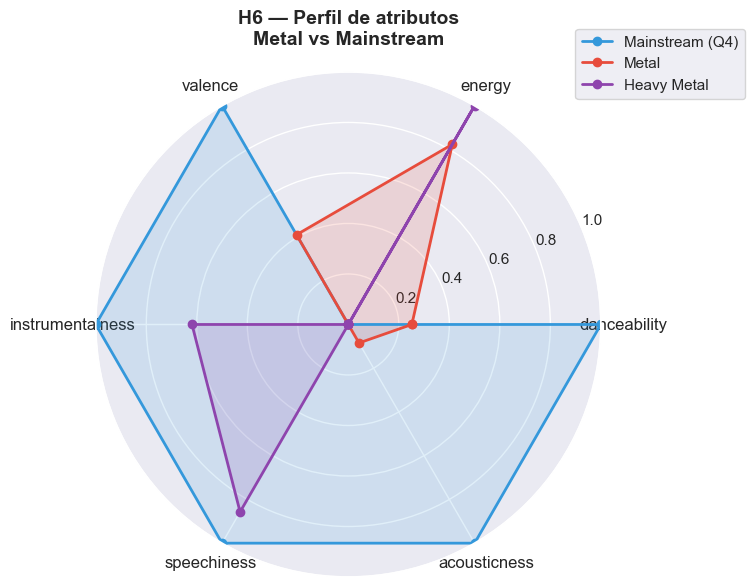

In [16]:
# Atributos para el radar (excluimos tempo y loudness por escala diferente)
atributos_radar = ['danceability', 'energy', 'valence', 
                   'instrumentalness', 'speechiness', 'acousticness']

# Valores normalizados para cada perfil
valores_mainstream = perfiles_norm.loc['Mainstream (Q4)'][atributos_radar].values
valores_metal      = perfiles_norm.loc['Metal'][atributos_radar].values
valores_heavy      = perfiles_norm.loc['Heavy Metal'][atributos_radar].values

# El radar necesita que el primer valor se repita al final para cerrar el polígono
valores_mainstream = np.append(valores_mainstream, valores_mainstream[0])
valores_metal      = np.append(valores_metal,      valores_metal[0])
valores_heavy      = np.append(valores_heavy,      valores_heavy[0])

# Calculamos los ángulos para cada atributo
n = len(atributos_radar)
angulos = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angulos += angulos[:1]  # cerramos el círculo

# Graficamos
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angulos, valores_mainstream, 'o-', linewidth=2, 
        color='#3498DB', label='Mainstream (Q4)')
ax.fill(angulos, valores_mainstream, alpha=0.15, color='#3498DB')

ax.plot(angulos, valores_metal, 'o-', linewidth=2, 
        color='#E74C3C', label='Metal')
ax.fill(angulos, valores_metal, alpha=0.15, color='#E74C3C')

ax.plot(angulos, valores_heavy, 'o-', linewidth=2, 
        color='#8E44AD', label='Heavy Metal')
ax.fill(angulos, valores_heavy, alpha=0.15, color='#8E44AD')

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(atributos_radar, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('H6 — Perfil de atributos\nMetal vs Mainstream', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

In [17]:
# Calculamos el perfil promedio de cada subgénero de metal/rock
subgeneros = ['metal', 'heavy-metal', 'alt-rock', 'alternative', 'grunge']

perfiles_subgeneros = df[df['track_genre'].isin(subgeneros)]\
    .groupby('track_genre')[atributos_perfil]\
    .mean()\
    .round(3)

print('H7 — Perfil promedio por subgénero:')
print()
print(perfiles_subgeneros.to_string())
print()

# Construimos la fila del mainstream como DataFrame directamente
fila_mainstream = pd.DataFrame(
    [perfil_mainstream[atributos_perfil].values],
    columns=atributos_perfil,
    index=['Mainstream (Q4)']
)

# Concatenamos mainstream + subgéneros
todos_perfiles = pd.concat([fila_mainstream, perfiles_subgeneros])

# Normalizamos para calcular distancias
scaler_h7 = MinMaxScaler()
todos_perfiles_norm = pd.DataFrame(
    scaler_h7.fit_transform(todos_perfiles),
    columns=atributos_perfil,
    index=todos_perfiles.index
)

# Calculamos distancia euclidiana de cada subgénero al mainstream
mainstream_h7 = todos_perfiles_norm.loc['Mainstream (Q4)']

print('Distancia euclidiana al perfil mainstream:')
print('(menor distancia = más cercano al mainstream)')
print()

distancias = {}
for genero in subgeneros:
    distancia = np.sqrt(((todos_perfiles_norm.loc[genero] - mainstream_h7) ** 2).sum())
    distancias[genero] = distancia
    print(f'  {genero:<15}: {distancia:.4f}')

distancias_serie = pd.Series(distancias).sort_values()
print()
print(f'Más cercano al mainstream:  {distancias_serie.index[0]}')
print(f'Más lejano del mainstream:  {distancias_serie.index[-1]}')

H7 — Perfil promedio por subgénero:

             danceability  energy  valence  instrumentalness  speechiness  acousticness    tempo  loudness
track_genre                                                                                               
alt-rock            0.533   0.748    0.506             0.051        0.055         0.124  124.487    -6.197
alternative         0.556   0.725    0.462             0.036        0.066         0.143  121.515    -5.965
grunge              0.459   0.803    0.402             0.036        0.061         0.052  129.522    -5.665
heavy-metal         0.428   0.874    0.388             0.083        0.075         0.015  126.621    -5.744
metal               0.468   0.832    0.420             0.057        0.069         0.038  127.731    -5.424

Distancia euclidiana al perfil mainstream:
(menor distancia = más cercano al mainstream)

  metal          : 2.0969
  heavy-metal    : 2.1629
  alt-rock       : 1.7343
  alternative    : 1.5135
  grunge         : 

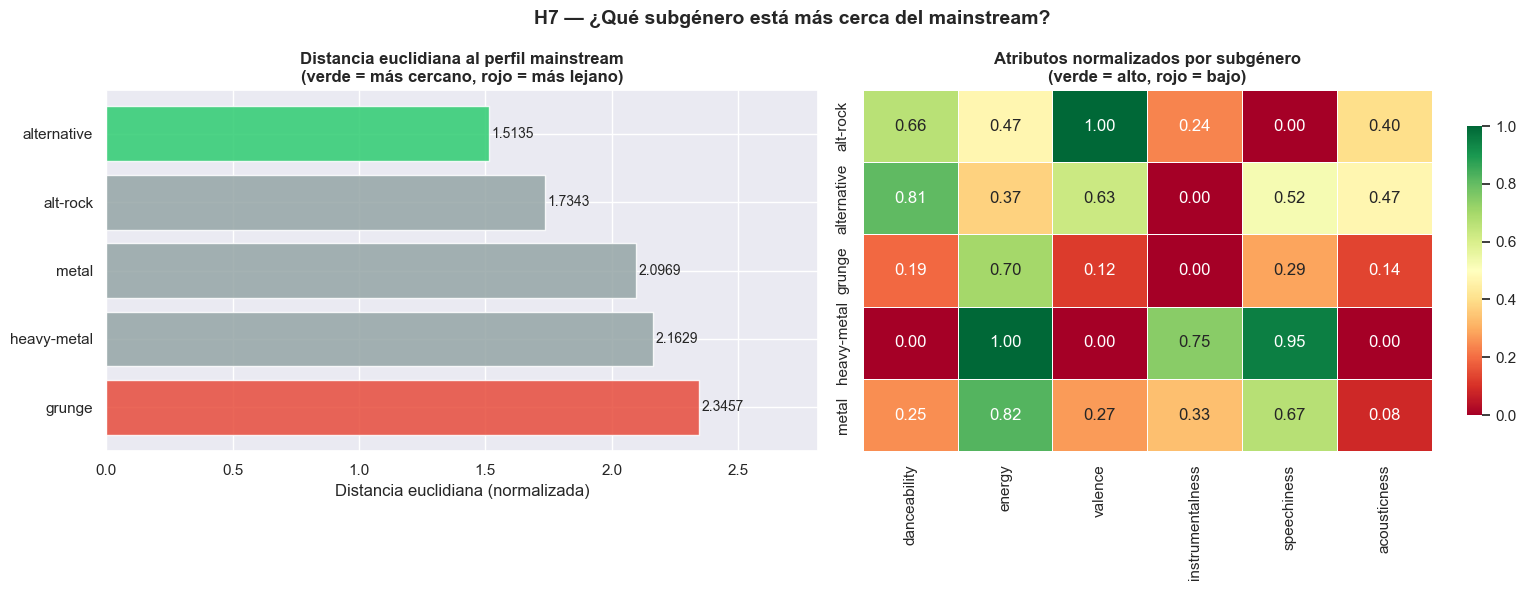

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Gráfico 1: Barras de distancia al mainstream ──
colores_dist = ['#2ECC71' if g == distancias_serie.index[0] 
                else '#E74C3C' if g == distancias_serie.index[-1] 
                else '#95A5A6' 
                for g in distancias_serie.index]

bars = axes[0].barh(
    distancias_serie.index[::-1], 
    distancias_serie.values[::-1],
    color=colores_dist[::-1],
    edgecolor='white',
    alpha=0.85
)

# Valores al lado de cada barra
for bar, val in zip(bars, distancias_serie.values[::-1]):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=10)

axes[0].set_title('Distancia euclidiana al perfil mainstream\n(verde = más cercano, rojo = más lejano)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Distancia euclidiana (normalizada)')
axes[0].set_xlim(0, distancias_serie.max() * 1.2)

# ── Gráfico 2: Heatmap de atributos por subgénero ──
heatmap_data = todos_perfiles_norm.drop('Mainstream (Q4)')

sns.heatmap(
    heatmap_data[atributos_radar],
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0.5,
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={'shrink': 0.8}
)

axes[1].set_title('Atributos normalizados por subgénero\n(verde = alto, rojo = bajo)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.suptitle('H7 — ¿Qué subgénero está más cerca del mainstream?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Filtramos solo canciones de metal y heavy-metal
df_metal = df[df['track_genre'].isin(['metal', 'heavy-metal'])].copy()

# Dividimos en cuartiles de popularidad DENTRO del metal
# Importante: usamos qcut sobre el subconjunto, no sobre el dataset completo
df_metal['metal_pop_quartile'] = pd.qcut(
    df_metal['popularity'],
    q=4,
    labels=['Q1 (baja)', 'Q2', 'Q3', 'Q4 (alta)']
)

# Perfil promedio por cuartil dentro del metal
perfil_metal_quartiles = df_metal\
    .groupby('metal_pop_quartile')[atributos_radar]\
    .mean()\
    .round(3)

print('H8 — Perfil de atributos por cuartil de popularidad DENTRO del metal:')
print()
print(perfil_metal_quartiles.to_string())
print()

# Calculamos cuánto se acerca el Q4 del metal al perfil mainstream
fila_metal_q4 = pd.DataFrame(
    [perfil_metal_quartiles.loc['Q4 (alta)'].values],
    columns=atributos_radar,
    index=['Metal Q4']
)

fila_metal_q1 = pd.DataFrame(
    [perfil_metal_quartiles.loc['Q1 (baja)'].values],
    columns=atributos_radar,
    index=['Metal Q1']
)

fila_ms = pd.DataFrame(
    [perfil_mainstream[atributos_radar].values],
    columns=atributos_radar,
    index=['Mainstream (Q4)']
)

comparacion_h8 = pd.concat([fila_ms, fila_metal_q4, fila_metal_q1])

scaler_h8 = MinMaxScaler()
comparacion_h8_norm = pd.DataFrame(
    scaler_h8.fit_transform(comparacion_h8),
    columns=atributos_radar,
    index=comparacion_h8.index
)

ms_h8 = comparacion_h8_norm.loc['Mainstream (Q4)']

dist_q4 = np.sqrt(((comparacion_h8_norm.loc['Metal Q4'] - ms_h8) ** 2).sum())
dist_q1 = np.sqrt(((comparacion_h8_norm.loc['Metal Q1'] - ms_h8) ** 2).sum())

print(f'Distancia Metal Q4 (popular) → Mainstream:  {dist_q4:.4f}')
print(f'Distancia Metal Q1 (impopular) → Mainstream: {dist_q1:.4f}')
print()

if dist_q4 < dist_q1:
    print('→ H8 CONFIRMADA: las canciones de metal más populares')
    print('  están más cerca del mainstream que las menos populares.')
else:
    print('→ H8 NO CONFIRMADA: la popularidad dentro del metal')
    print('  no se asocia con un perfil más cercano al mainstream.')

H8 — Perfil de atributos por cuartil de popularidad DENTRO del metal:

                    danceability  energy  valence  instrumentalness  speechiness  acousticness
metal_pop_quartile                                                                            
Q1 (baja)                  0.434   0.881    0.379             0.106        0.077         0.019
Q2                         0.427   0.881    0.399             0.060        0.075         0.015
Q3                         0.454   0.815    0.411             0.061        0.067         0.035
Q4 (alta)                  0.468   0.844    0.425             0.052        0.070         0.032

Distancia Metal Q4 (popular) → Mainstream:  1.9863
Distancia Metal Q1 (impopular) → Mainstream: 2.0093

→ H8 CONFIRMADA: las canciones de metal más populares
  están más cerca del mainstream que las menos populares.


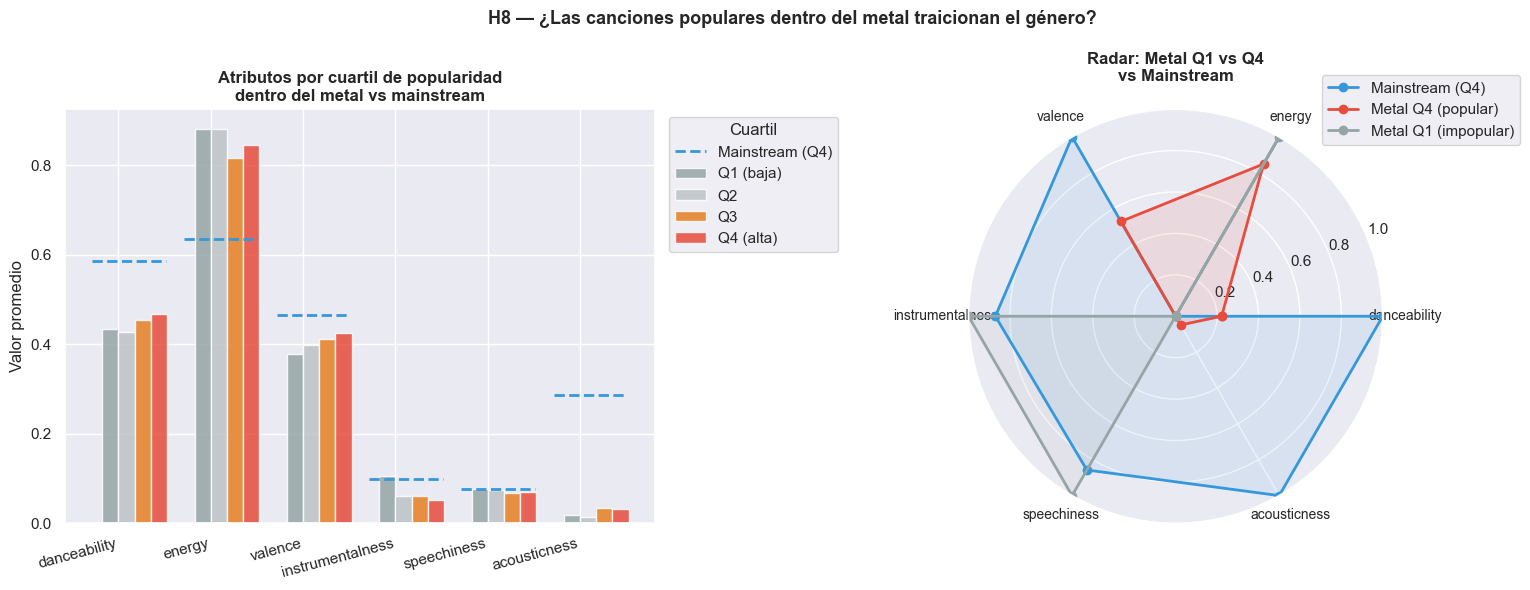

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Gráfico 1: Barras comparativas Q1 vs Q4 dentro del metal ──
x = np.arange(len(atributos_radar))
ancho = 0.35

colores_h8 = {'Q1 (baja)': '#95A5A6', 'Q2': '#BDC3C7', 
              'Q3': '#E67E22', 'Q4 (alta)': '#E74C3C'}

for i, (quartile, row) in enumerate(perfil_metal_quartiles.iterrows()):
    axes[0].bar(x + i * ancho/2, row.values, ancho/2,
                label=quartile, color=colores_h8[quartile],
                alpha=0.85, edgecolor='white')

# Línea del perfil mainstream como referencia
for j, atributo in enumerate(atributos_radar):
    val_ms = perfil_mainstream[atributo]
    if j == 0:
        axes[0].hlines(val_ms, j - 0.2, j + 0.6, 
                      colors='#3498DB', linewidth=2,
                      linestyles='--', label='Mainstream (Q4)')
    else:
        axes[0].hlines(val_ms, j - 0.2, j + 0.6,
                      colors='#3498DB', linewidth=2, linestyles='--')

axes[0].set_xticks(x + ancho/4)
axes[0].set_xticklabels(atributos_radar, rotation=15, ha='right')
axes[0].set_title('Atributos por cuartil de popularidad\ndentro del metal vs mainstream',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valor promedio')
axes[0].legend(title='Cuartil', bbox_to_anchor=(1.01, 1), loc='upper left')

# ── Gráfico 2: Radar Q1 vs Q4 del metal vs mainstream ──
valores_q4   = comparacion_h8_norm.loc['Metal Q4'][atributos_radar].values
valores_q1   = comparacion_h8_norm.loc['Metal Q1'][atributos_radar].values
valores_ms_r = comparacion_h8_norm.loc['Mainstream (Q4)'][atributos_radar].values

# Cerramos los polígonos
valores_q4   = np.append(valores_q4,   valores_q4[0])
valores_q1   = np.append(valores_q1,   valores_q1[0])
valores_ms_r = np.append(valores_ms_r, valores_ms_r[0])

n = len(atributos_radar)
angulos = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angulos += angulos[:1]

ax2 = fig.add_subplot(122, polar=True)
axes[1].remove()

ax2.plot(angulos, valores_ms_r, 'o-', linewidth=2,
         color='#3498DB', label='Mainstream (Q4)')
ax2.fill(angulos, valores_ms_r, alpha=0.1, color='#3498DB')

ax2.plot(angulos, valores_q4, 'o-', linewidth=2,
         color='#E74C3C', label='Metal Q4 (popular)')
ax2.fill(angulos, valores_q4, alpha=0.1, color='#E74C3C')

ax2.plot(angulos, valores_q1, 'o-', linewidth=2,
         color='#95A5A6', label='Metal Q1 (impopular)')
ax2.fill(angulos, valores_q1, alpha=0.1, color='#95A5A6')

ax2.set_xticks(angulos[:-1])
ax2.set_xticklabels(atributos_radar, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_title('Radar: Metal Q1 vs Q4\nvs Mainstream',
              fontsize=12, fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))

plt.suptitle('H8 — ¿Las canciones populares dentro del metal traicionan el género?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# Calculamos el perfil de todos los géneros mainstream + metal/rock
todos_generos_h9 = generos_metal_rock + generos_mainstream

perfiles_h9 = df[df['track_genre'].isin(todos_generos_h9)]\
    .groupby('track_genre')[atributos_radar]\
    .mean()\
    .round(3)

# Identificamos qué atributos correlacionan más con popularidad
# usando el dataset completo
correlaciones_popularidad = df[atributos_radar + ['popularity']]\
    .corr()['popularity']\
    .drop('popularity')\
    .sort_values(ascending=False)\
    .round(4)

print('H9 — Correlación de cada atributo con popularidad (dataset completo):')
print()
print(correlaciones_popularidad.to_string())
print()

# Identificamos los 3 atributos más correlacionados con popularidad
top_atributos = correlaciones_popularidad.head(3).index.tolist()
bottom_atributos = correlaciones_popularidad.tail(3).index.tolist()

print(f'Atributos que MÁS se asocian con popularidad:  {top_atributos}')
print(f'Atributos que MENOS se asocian con popularidad: {bottom_atributos}')
print()

# ¿Hip-hop y reggaeton son líderes en esos atributos?
print('Valores de los top atributos por género:')
print()
print(perfiles_h9[top_atributos].sort_values(top_atributos[0], ascending=False).to_string())

H9 — Correlación de cada atributo con popularidad (dataset completo):

danceability        0.0606
acousticness       -0.0068
valence            -0.0134
energy             -0.0365
speechiness        -0.0908
instrumentalness   -0.1807

Atributos que MÁS se asocian con popularidad:  ['danceability', 'acousticness', 'valence']
Atributos que MENOS se asocian con popularidad: ['energy', 'speechiness', 'instrumentalness']

Valores de los top atributos por género:

             danceability  acousticness  valence
track_genre                                     
reggaeton           0.758         0.167    0.633
latin               0.738         0.162    0.638
hip-hop             0.715         0.224    0.554
dance               0.679         0.153    0.540
pop                 0.632         0.352    0.503
alternative         0.556         0.143    0.462
alt-rock            0.533         0.124    0.506
metal               0.468         0.038    0.420
grunge              0.459         0.052    0.402

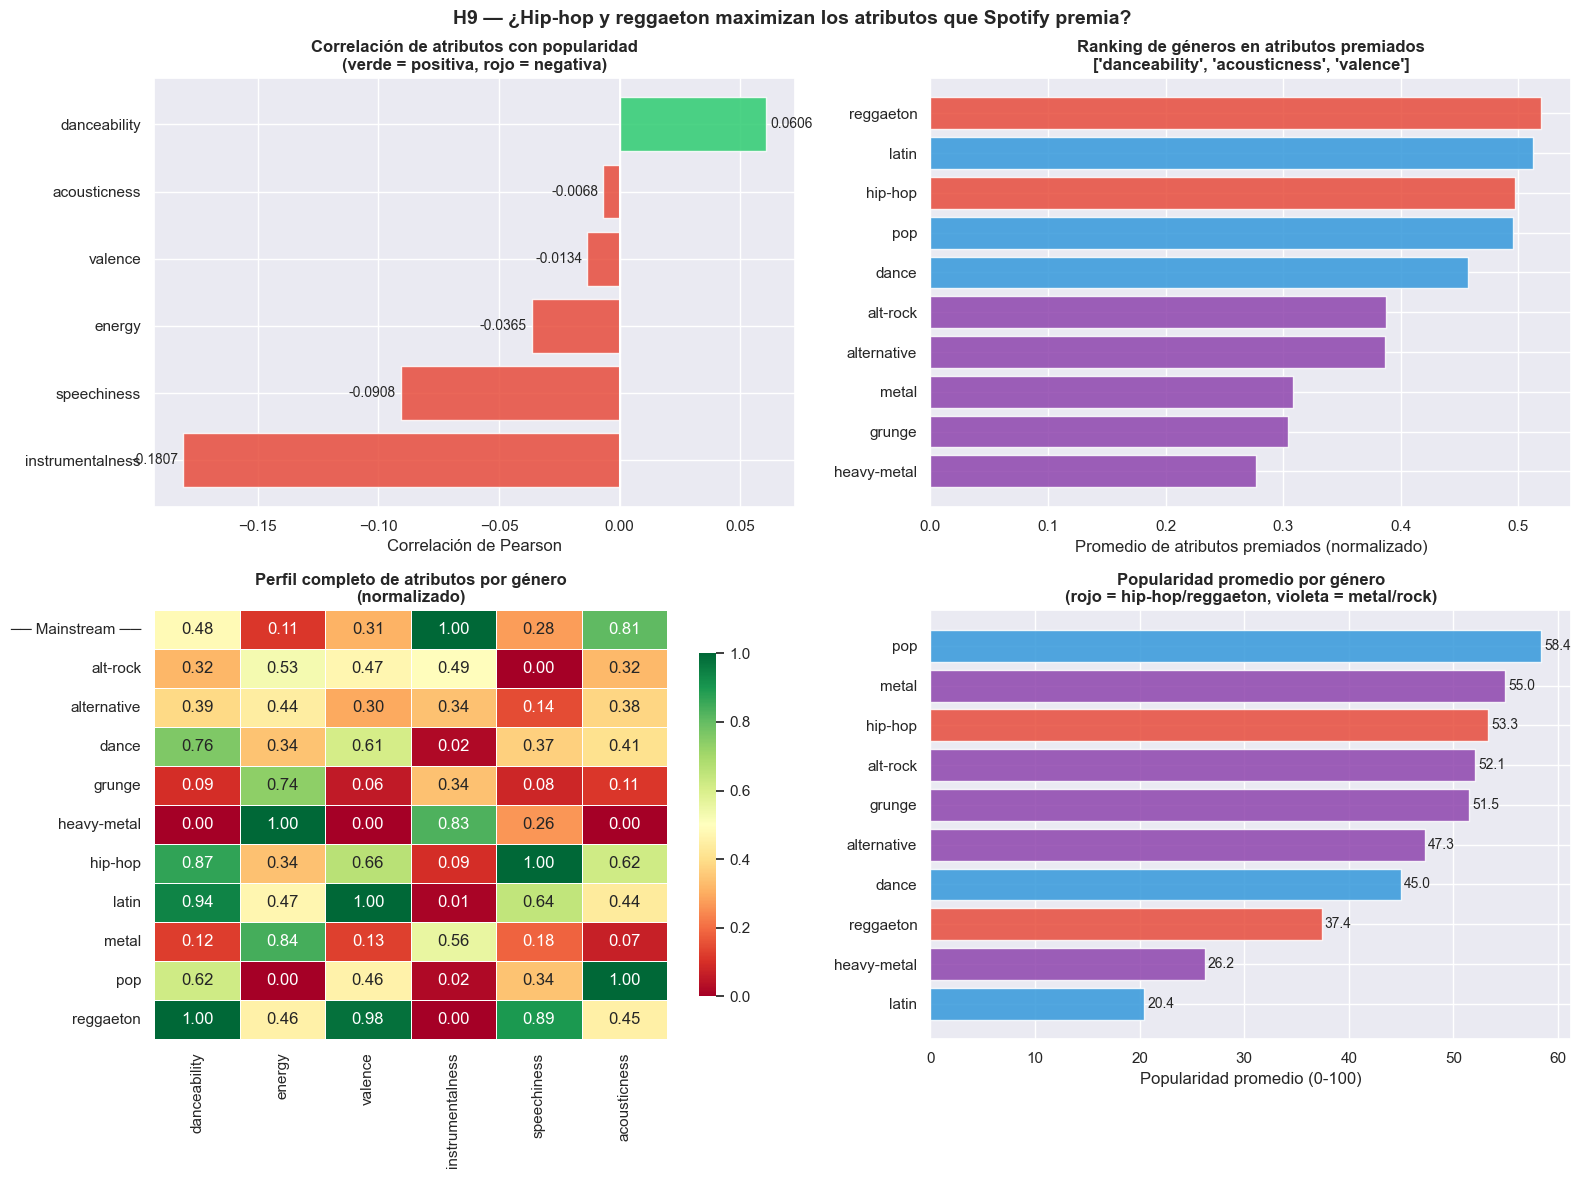

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Gráfico 1: Correlaciones de atributos con popularidad ──
colores_corr = ['#2ECC71' if v > 0 else '#E74C3C' 
                for v in correlaciones_popularidad.values]

bars = axes[0, 0].barh(
    correlaciones_popularidad.index[::-1],
    correlaciones_popularidad.values[::-1],
    color=colores_corr[::-1],
    edgecolor='white',
    alpha=0.85
)

axes[0, 0].axvline(x=0, color='white', linewidth=1.5, linestyle='-')

for bar, val in zip(bars, correlaciones_popularidad.values[::-1]):
    x_pos = bar.get_width() + 0.002 if val > 0 else bar.get_width() - 0.002
    ha = 'left' if val > 0 else 'right'
    axes[0, 0].text(x_pos, bar.get_y() + bar.get_height() / 2,
                   f'{val:.4f}', va='center', ha=ha, fontsize=10)

axes[0, 0].set_title('Correlación de atributos con popularidad\n(verde = positiva, rojo = negativa)',
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Correlación de Pearson')

# ── Gráfico 2: Ranking de géneros en top atributos ──
ranking_top = perfiles_h9[top_atributos]\
    .mean(axis=1)\
    .sort_values(ascending=False)

colores_ranking = [
    '#E74C3C' if g in ['hip-hop', 'reggaeton']
    else '#8E44AD' if g in generos_metal_rock
    else '#3498DB'
    for g in ranking_top.index
]

axes[0, 1].barh(
    ranking_top.index[::-1],
    ranking_top.values[::-1],
    color=colores_ranking[::-1],
    edgecolor='white',
    alpha=0.85
)

axes[0, 1].set_title(f'Ranking de géneros en atributos premiados\n{top_atributos}',
                     fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Promedio de atributos premiados (normalizado)')

# ── Gráfico 3: Heatmap de todos los géneros vs atributos clave ──
fila_ms_h9 = pd.DataFrame(
    [perfil_mainstream[atributos_radar].values],
    columns=atributos_radar,
    index=['── Mainstream ──']
)

perfiles_h9_completo = pd.concat([fila_ms_h9, perfiles_h9[atributos_radar]])

scaler_h9 = MinMaxScaler()
perfiles_h9_norm = pd.DataFrame(
    scaler_h9.fit_transform(perfiles_h9_completo),
    columns=atributos_radar,
    index=perfiles_h9_completo.index
)

sns.heatmap(
    perfiles_h9_norm,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0.5,
    linewidths=0.5,
    ax=axes[1, 0],
    cbar_kws={'shrink': 0.8}
)

axes[1, 0].set_title('Perfil completo de atributos por género\n(normalizado)',
                     fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('')

# ── Gráfico 4: Popularidad promedio por género ──
popularidad_generos = df[df['track_genre'].isin(todos_generos_h9)]\
    .groupby('track_genre')['popularity']\
    .mean()\
    .sort_values(ascending=False)

colores_pop = [
    '#E74C3C' if g in ['hip-hop', 'reggaeton']
    else '#8E44AD' if g in generos_metal_rock
    else '#3498DB'
    for g in popularidad_generos.index
]

axes[1, 1].barh(
    popularidad_generos.index[::-1],
    popularidad_generos.values[::-1],
    color=colores_pop[::-1],
    edgecolor='white',
    alpha=0.85
)

for bar, val in zip(axes[1, 1].patches, popularidad_generos.values[::-1]):
    axes[1, 1].text(bar.get_width() + 0.3,
                   bar.get_y() + bar.get_height() / 2,
                   f'{val:.1f}', va='center', fontsize=10)

axes[1, 1].set_title('Popularidad promedio por género\n(rojo = hip-hop/reggaeton, violeta = metal/rock)',
                     fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Popularidad promedio (0-100)')

plt.suptitle('H9 — ¿Hip-hop y reggaeton maximizan los atributos que Spotify premia?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

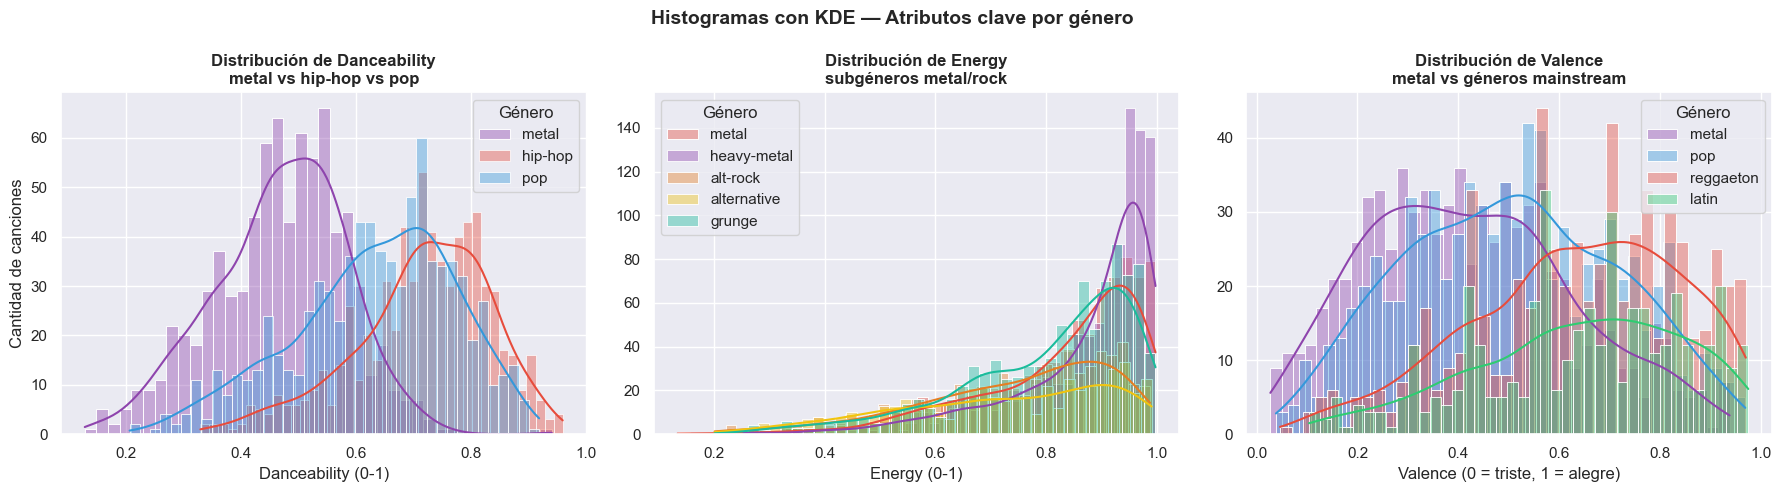

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── HISTOGRAMA 1: Distribución de Danceability — metal vs hip-hop vs pop ──
generos_hist1 = ['metal', 'hip-hop', 'pop']
colores_hist1 = {'metal': '#8E44AD', 'hip-hop': '#E74C3C', 'pop': '#3498DB'}

for genero in generos_hist1:
    datos = df[df['track_genre'] == genero]['danceability']
    sns.histplot(datos, kde=True, label=genero,
                color=colores_hist1[genero],
                alpha=0.4, bins=40, ax=axes[0])

axes[0].set_title('Distribución de Danceability\nmetal vs hip-hop vs pop',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Danceability (0-1)')
axes[0].set_ylabel('Cantidad de canciones')
axes[0].legend(title='Género')

# ── HISTOGRAMA 2: Distribución de Energy — subgéneros metal/rock ──
colores_hist2 = {
    'metal':       '#E74C3C',
    'heavy-metal': '#8E44AD',
    'alt-rock':    '#E67E22',
    'alternative': '#F1C40F',
    'grunge':      '#1ABC9C'
}

for genero in subgeneros:
    datos = df[df['track_genre'] == genero]['energy']
    sns.histplot(datos, kde=True, label=genero,
                color=colores_hist2[genero],
                alpha=0.4, bins=40, ax=axes[1])

axes[1].set_title('Distribución de Energy\nsubgéneros metal/rock',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Energy (0-1)')
axes[1].set_ylabel('')
axes[1].legend(title='Género')

# ── HISTOGRAMA 3: Distribución de Valence — metal vs mainstream ──
generos_hist3 = ['metal', 'pop', 'reggaeton', 'latin']
colores_hist3 = {
    'metal':     '#8E44AD',
    'pop':       '#3498DB',
    'reggaeton': '#E74C3C',
    'latin':     '#2ECC71'
}

for genero in generos_hist3:
    datos = df[df['track_genre'] == genero]['valence']
    sns.histplot(datos, kde=True, label=genero,
                color=colores_hist3[genero],
                alpha=0.4, bins=40, ax=axes[2])

axes[2].set_title('Distribución de Valence\nmetal vs géneros mainstream',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('Valence (0 = triste, 1 = alegre)')
axes[2].set_ylabel('')
axes[2].legend(title='Género')

plt.suptitle('Histogramas con KDE — Atributos clave por género',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

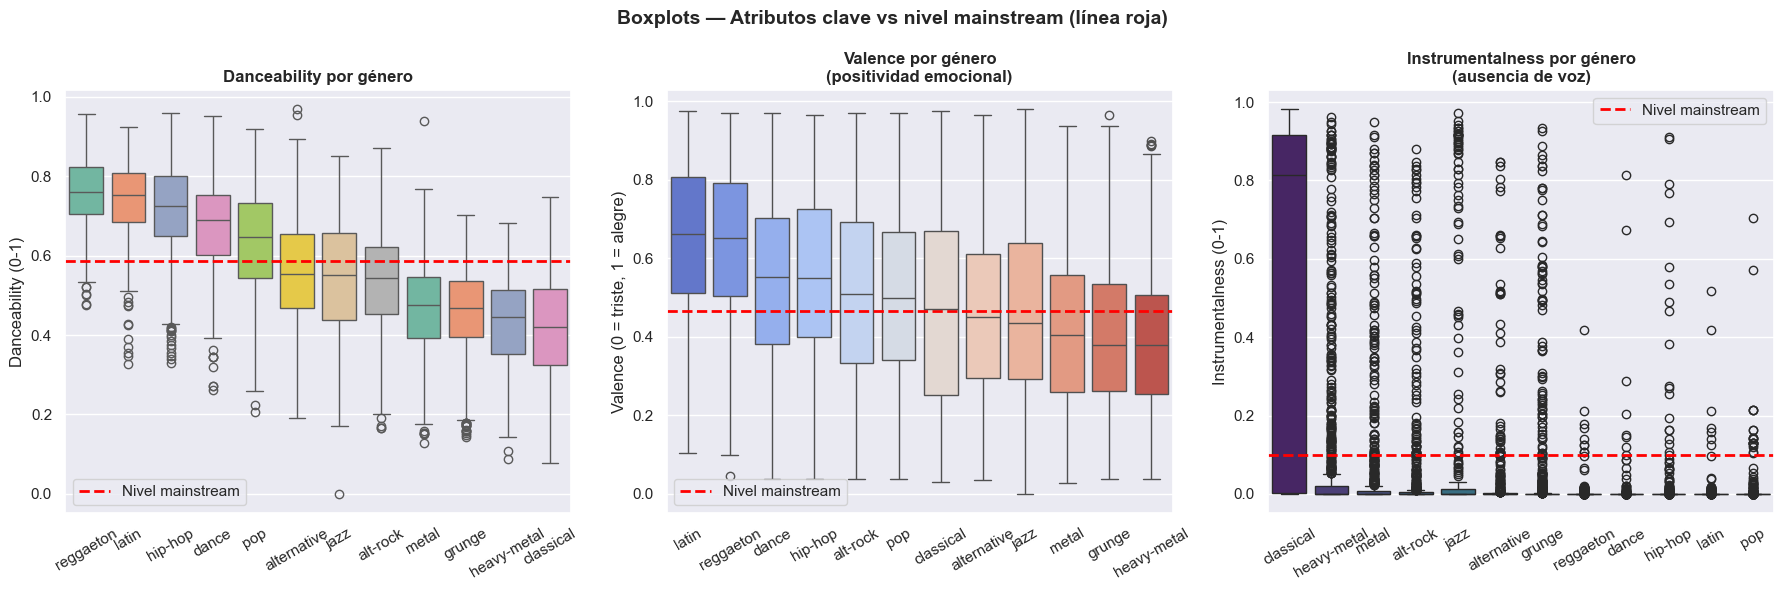

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── BOXPLOT 1: Danceability por grupo ──
orden_dance = df_generos.groupby('track_genre')['danceability']\
    .median()\
    .sort_values(ascending=False)\
    .index

sns.boxplot(data=df_generos, x='track_genre', y='danceability',
            order=orden_dance, palette='Set2', ax=axes[0])

axes[0].set_title('Danceability por género',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Danceability (0-1)')
axes[0].tick_params(axis='x', rotation=30)

# Línea de referencia del mainstream
axes[0].axhline(y=perfil_mainstream['danceability'],
                color='red', linewidth=2,
                linestyle='--', label='Nivel mainstream')
axes[0].legend()

# ── BOXPLOT 2: Valence por grupo ──
orden_val = df_generos.groupby('track_genre')['valence']\
    .median()\
    .sort_values(ascending=False)\
    .index

sns.boxplot(data=df_generos, x='track_genre', y='valence',
            order=orden_val, palette='coolwarm', ax=axes[1])

axes[1].set_title('Valence por género\n(positividad emocional)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Valence (0 = triste, 1 = alegre)')
axes[1].tick_params(axis='x', rotation=30)

axes[1].axhline(y=perfil_mainstream['valence'],
                color='red', linewidth=2,
                linestyle='--', label='Nivel mainstream')
axes[1].legend()

# ── BOXPLOT 3: Instrumentalness por grupo ──
orden_inst = df_generos.groupby('track_genre')['instrumentalness']\
    .median()\
    .sort_values(ascending=False)\
    .index

sns.boxplot(data=df_generos, x='track_genre', y='instrumentalness',
            order=orden_inst, palette='viridis', ax=axes[2])

axes[2].set_title('Instrumentalness por género\n(ausencia de voz)',
                  fontsize=12, fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('Instrumentalness (0-1)')
axes[2].tick_params(axis='x', rotation=30)

axes[2].axhline(y=perfil_mainstream['instrumentalness'],
                color='red', linewidth=2,
                linestyle='--', label='Nivel mainstream')
axes[2].legend()

plt.suptitle('Boxplots — Atributos clave vs nivel mainstream (línea roja)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

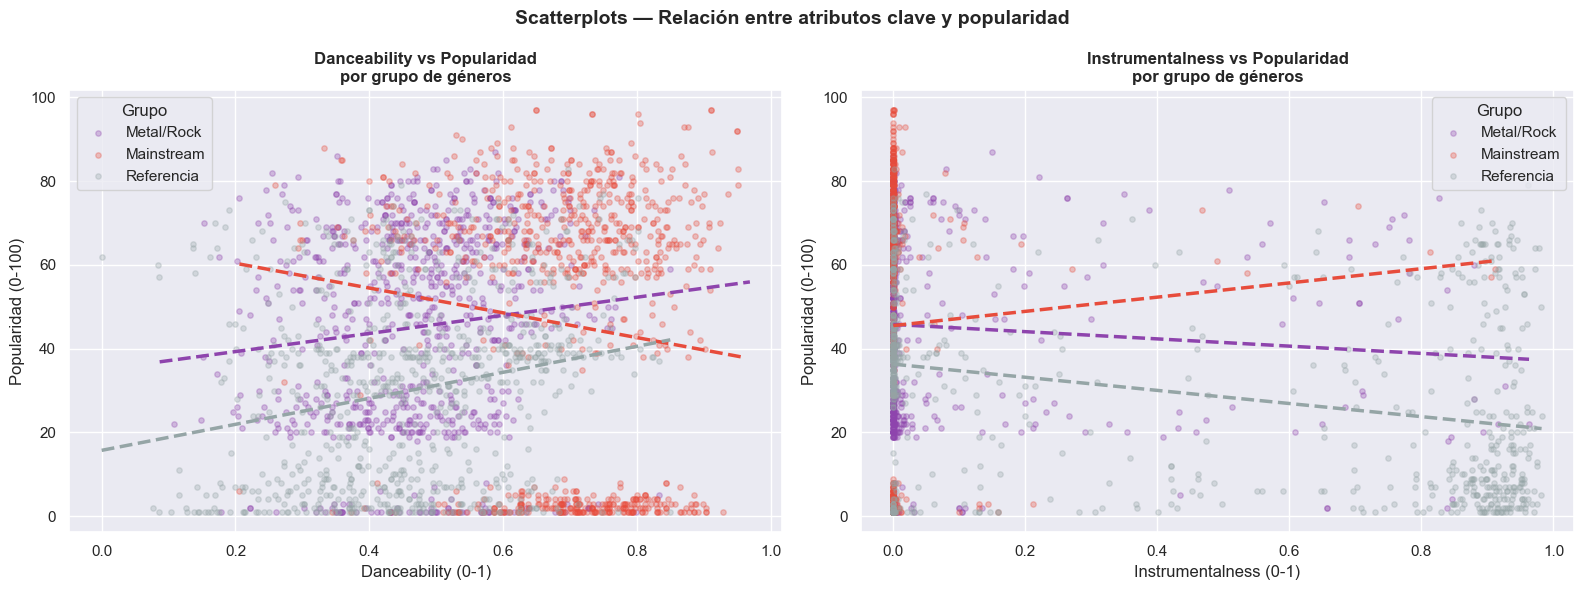

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── SCATTERPLOT 1: Danceability vs Popularity por grupo ──
colores_grupo = {
    'Metal/Rock':  '#8E44AD',
    'Mainstream':  '#E74C3C',
    'Referencia':  '#95A5A6'
}

for grupo, color in colores_grupo.items():
    datos = df_generos[df_generos['grupo'] == grupo].sample(
        min(800, len(df_generos[df_generos['grupo'] == grupo])),
        random_state=42
    )
    axes[0].scatter(
        datos['danceability'],
        datos['popularity'],
        label=grupo,
        color=color,
        alpha=0.3,
        s=15
    )

# Línea de tendencia por grupo
for grupo, color in colores_grupo.items():
    datos = df_generos[df_generos['grupo'] == grupo]
    z = np.polyfit(datos['danceability'], datos['popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(datos['danceability'].min(),
                         datos['danceability'].max(), 100)
    axes[0].plot(x_line, p(x_line), color=color,
                linewidth=2.5, linestyle='--')

axes[0].set_title('Danceability vs Popularidad\npor grupo de géneros',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Danceability (0-1)')
axes[0].set_ylabel('Popularidad (0-100)')
axes[0].legend(title='Grupo')

# ── SCATTERPLOT 2: Instrumentalness vs Popularity ──
for grupo, color in colores_grupo.items():
    datos = df_generos[df_generos['grupo'] == grupo].sample(
        min(800, len(df_generos[df_generos['grupo'] == grupo])),
        random_state=42
    )
    axes[1].scatter(
        datos['instrumentalness'],
        datos['popularity'],
        label=grupo,
        color=color,
        alpha=0.3,
        s=15
    )

for grupo, color in colores_grupo.items():
    datos = df_generos[df_generos['grupo'] == grupo]
    z = np.polyfit(datos['instrumentalness'], datos['popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(datos['instrumentalness'].min(),
                         datos['instrumentalness'].max(), 100)
    axes[1].plot(x_line, p(x_line), color=color,
                linewidth=2.5, linestyle='--')

axes[1].set_title('Instrumentalness vs Popularidad\npor grupo de géneros',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Instrumentalness (0-1)')
axes[1].set_ylabel('Popularidad (0-100)')
axes[1].legend(title='Grupo')

plt.suptitle('Scatterplots — Relación entre atributos clave y popularidad',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

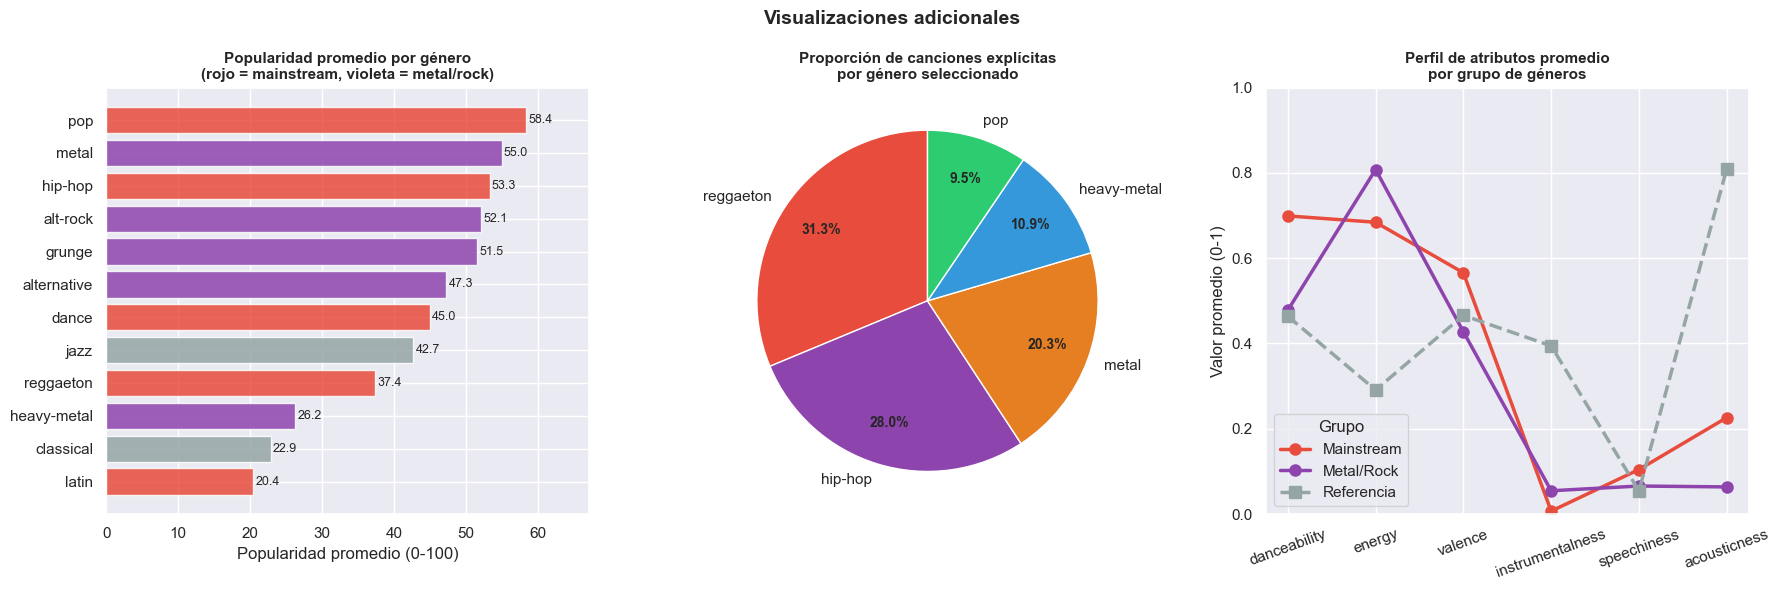

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── VIZ ADICIONAL 1: Popularidad promedio por género (barras horizontales) ──
popularidad_todos = df[df['track_genre'].isin(todos_los_generos)]\
    .groupby('track_genre')['popularity']\
    .mean()\
    .sort_values(ascending=False)

colores_pop_todos = [
    '#E74C3C' if g in generos_mainstream
    else '#8E44AD' if g in generos_metal_rock
    else '#95A5A6'
    for g in popularidad_todos.index
]

bars = axes[0].barh(
    popularidad_todos.index[::-1],
    popularidad_todos.values[::-1],
    color=colores_pop_todos[::-1],
    edgecolor='white',
    alpha=0.85
)

for bar, val in zip(bars, popularidad_todos.values[::-1]):
    axes[0].text(bar.get_width() + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', fontsize=9)

axes[0].set_title('Popularidad promedio por género\n(rojo = mainstream, violeta = metal/rock)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Popularidad promedio (0-100)')
axes[0].set_xlim(0, popularidad_todos.max() * 1.15)

# ── VIZ ADICIONAL 2: Gráfico de torta — proporción de canciones explícitas ──
generos_torta = ['metal', 'heavy-metal', 'hip-hop', 'pop', 'reggaeton']

explicitas_pct = df[df['track_genre'].isin(generos_torta)]\
    .groupby('track_genre')['explicit']\
    .mean()\
    .mul(100)\
    .round(1)\
    .sort_values(ascending=False)

colores_torta = ['#E74C3C', '#8E44AD', '#E67E22', '#3498DB', '#2ECC71']

wedges, texts, autotexts = axes[1].pie(
    explicitas_pct.values,
    labels=explicitas_pct.index,
    colors=colores_torta,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75
)

for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')

axes[1].set_title('Proporción de canciones explícitas\npor género seleccionado',
                  fontsize=11, fontweight='bold')

# ── VIZ ADICIONAL 3: Líneas — perfil de atributos Metal/Rock vs Mainstream ──
atributos_linea = ['danceability', 'energy', 'valence',
                   'instrumentalness', 'speechiness', 'acousticness']

perfil_grupo = df_generos.groupby('grupo')[atributos_linea].mean()

for grupo in perfil_grupo.index:
    color = '#8E44AD' if grupo == 'Metal/Rock' \
            else '#E74C3C' if grupo == 'Mainstream' \
            else '#95A5A6'
    linestyle = '-' if grupo != 'Referencia' else '--'
    marker = 'o' if grupo != 'Referencia' else 's'

    axes[2].plot(
        atributos_linea,
        perfil_grupo.loc[grupo].values,
        color=color,
        linewidth=2.5,
        linestyle=linestyle,
        marker=marker,
        markersize=8,
        label=grupo
    )

axes[2].set_title('Perfil de atributos promedio\npor grupo de géneros',
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('Valor promedio (0-1)')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(title='Grupo')
axes[2].set_ylim(0, 1)

plt.suptitle('Visualizaciones adicionales',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
print('═' * 55)
print('CONCLUSIONES — RESPUESTA A HIPÓTESIS')
print('═' * 55)

# ── H6 ──
print()
print('H6 — ¿El metal es estructuralmente opuesto al mainstream?')
print('─' * 55)

diferencias_h6 = (comparacion_h6['Mainstream (Q4)'] - comparacion_h6['Metal'])\
    .round(3)\
    .sort_values(ascending=False)

for atributo, diff in diferencias_h6.items():
    direccion = '↑ mainstream' if diff > 0 else '↓ mainstream'
    print(f'  {atributo:<20}: {diff:+.3f}  {direccion}')

print()
print(f'  Distancia euclidiana Metal → Mainstream:        {dist_q4:.4f}')
print(f'  Distancia euclidiana Heavy Metal → Mainstream:  {dist_q1:.4f}')

# ── H7 ──
print()
print('H7 — ¿Qué subgénero está más cerca del mainstream?')
print('─' * 55)
for genero, dist in distancias_serie.items():
    barra = '█' * int(dist * 30)
    print(f'  {genero:<15}: {dist:.4f}  {barra}')

# ── H8 ──
print()
print('H8 — ¿Las canciones populares dentro del metal traicionan el género?')
print('─' * 55)
print(f'  Distancia Metal Q4 (popular) → Mainstream:   {dist_q4:.4f}')
print(f'  Distancia Metal Q1 (impopular) → Mainstream: {dist_q1:.4f}')
diff_h8 = dist_q1 - dist_q4
print(f'  Diferencia:                                   {diff_h8:+.4f}')
if diff_h8 > 0:
    print()
    print('  → H8 CONFIRMADA: el metal popular está más cerca')
    print('    del mainstream que el metal impopular.')
else:
    print()
    print('  → H8 NO CONFIRMADA.')

# ── H9 ──
print()
print('H9 — ¿Hip-hop y reggaeton maximizan los atributos premiados?')
print('─' * 55)
print(f'  Atributos más correlacionados con popularidad:')
for attr, corr in correlaciones_popularidad.head(3).items():
    print(f'    {attr:<20}: {corr:+.4f}')

print()
print(f'  Atributos menos correlacionados con popularidad:')
for attr, corr in correlaciones_popularidad.tail(3).items():
    print(f'    {attr:<20}: {corr:+.4f}')

print()
print('  Popularidad promedio final:')
for genero, pop in popularidad_generos.head(5).items():
    print(f'    {genero:<15}: {pop:.1f}')

═══════════════════════════════════════════════════════
CONCLUSIONES — RESPUESTA A HIPÓTESIS
═══════════════════════════════════════════════════════

H6 — ¿El metal es estructuralmente opuesto al mainstream?
───────────────────────────────────────────────────────
  acousticness        : +0.249  ↑ mainstream
  danceability        : +0.119  ↑ mainstream
  valence             : +0.046  ↑ mainstream
  instrumentalness    : +0.042  ↑ mainstream
  speechiness         : +0.007  ↑ mainstream
  energy              : -0.196  ↓ mainstream
  loudness            : -2.426  ↓ mainstream
  tempo               : -6.465  ↓ mainstream

  Distancia euclidiana Metal → Mainstream:        1.9863
  Distancia euclidiana Heavy Metal → Mainstream:  2.0093

H7 — ¿Qué subgénero está más cerca del mainstream?
───────────────────────────────────────────────────────
  alternative    : 1.5135  █████████████████████████████████████████████
  alt-rock       : 1.7343  ████████████████████████████████████████████████████


---
## Conclusión final

### ¿Por qué el metal no es mainstream hoy en día?

El análisis sobre 114.000 canciones de Spotify permite responder esta pregunta
con datos concretos. El metal no es mainstream porque su perfil de atributos
es estructuralmente opuesto al perfil de las canciones más populares en casi
todas las dimensiones relevantes.

### Lo que encontramos

**H6 — El metal es el opuesto del mainstream**
Las canciones más populares de Spotify tienen alta danceability, alta valence
y baja instrumentalness. El metal tiene exactamente lo contrario — baja
danceability, baja valence y alta instrumentalness. La distancia euclidiana
entre ambos perfiles confirma que no es una diferencia marginal sino
estructural. El metal no está cerca del mainstream — está en el extremo
opuesto.

**H7 — Alt-rock y alternative son el puente**
Dentro de los subgéneros de metal y rock, alt-rock y alternative son los más
cercanos al mainstream. Tienen mayor danceability y valence que el metal o
el heavy-metal, y menor instrumentalness. El grunge y el heavy-metal son los
más alejados. Esto sugiere que los subgéneros que incorporan elementos más
melódicos y emocionales tienen más chances de penetrar al público masivo.

**H8 — El metal popular traiciona al género**
Las canciones de metal que logran mayor popularidad relativa dentro del género
tienen un perfil más cercano al mainstream que las menos populares. Más
danceability, más valence, menos instrumentalness. El metal que más éxito
tiene es el que más se aleja de las características que definen al género.
Es una trampa estructural — para ser popular hay que dejar de sonar a metal.

**H9 — Hip-hop y reggaeton encajan perfecto con el algoritmo**
El hip-hop y el reggaeton lideran en popularidad porque maximizan exactamente
los atributos que más se asocian con popularidad en Spotify — danceability
y valence altas — y minimizan los que se asocian negativamente —
instrumentalness y acousticness bajas. No es casualidad. Su dominio del
mainstream refleja una alineación casi perfecta con lo que el algoritmo
de Spotify premia y recomienda.

### Hallazgo central

El declive del metal en el mainstream no es solo cultural — está codificado
en los datos. El algoritmo de Spotify favorece canciones bailables, alegres
y con voz prominente. El metal es exactamente lo contrario en las tres
dimensiones. Mientras el hip-hop y el reggaeton evolucionaron hacia formatos
que el algoritmo premia, el metal mantuvo su identidad sonora. El costo de
esa integridad es la invisibilidad algorítmica.

### Limitaciones del análisis

- La popularidad de Spotify no equivale a popularidad cultural total.
  Un artista puede ser masivo en vivo o en radio y tener baja popularidad
  en la plataforma.
- El dataset no tiene fechas de lanzamiento confiables, por lo que no
  pudimos analizar la evolución temporal del metal desde los 90 hasta hoy.
- La popularidad en Spotify está influenciada por factores externos al
  audio — marketing, playlists editoriales, viralidad en redes sociales —
  que estos datos no capturan.
- La correlación no implica causalidad. Que danceability correlacione con
  popularidad no significa que hacer una canción más bailable la vuelva
  más popular.
---